# Fig 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import src.plot_graph as spg
import src.distance_utils as sdu
import src.plot_analysis as spa
import src.augment_data as sad

from src.config import PATHS

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [4]:
core_dt, task1_dt, task2_dt, task3_dt, task4_dt, task3_4_dt = sad.load_full_data(
    excl_incompl=True,
    excl_cheaters=True,
    excl_uncertains=True,
    verbose=0,
)

## Congruency

In [6]:
adj_m = core_dt["adj_m"].iloc[0]
wadj_m = core_dt["posw_adj_m"].iloc[0]
spd_m = core_dt["spd_m"].iloc[0]
wspd_m = core_dt["wspd_m"].iloc[0]
eucd_m = core_dt["eucd_m"].iloc[0]
pos = core_dt["node_positions"].iloc[0]

In [7]:
task3_4_dt_rot = task3_4_dt[task3_4_dt["var_type"]=="rotational"]
task3_4_dt_unc = task3_4_dt[task3_4_dt["var_type"]=="unconstrained"]

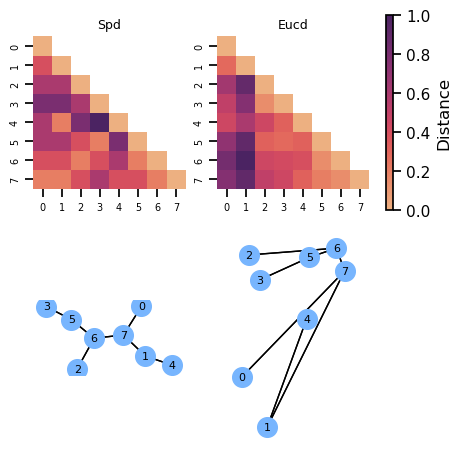

In [8]:
preds = [
    "spd_m_flat",
    "eucd_m_flat",
]
subj_ind = 13

fig, axs = spa.visualize_task4_predictors(task3_4_dt_rot, preds, cols=len(preds), subj_ind=subj_ind, diagonal=True)
fig.set_size_inches(4.5, 4.5)
plt.show()

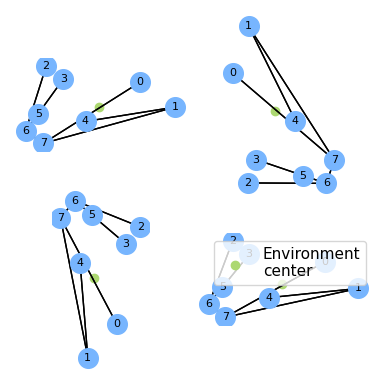

In [9]:
np.random.seed(131)
angle_rads = np.random.uniform(0, 2 * np.pi, 5)

fig, axs = plt.subplots(2,2, figsize=(4,4))
axs = axs.flatten()
n_colors = ["#b1d5fe", "#77b5fe"]
center = (450, 450)
pos_rot = spg.rotate_points(center, pos, angle_rads[0])
for ax in axs:
    ax.scatter(*center, c="#acd871", label="Environment\ncenter")
spg.axplot_graph(adj_m, pos=pos_rot, node_color=n_colors[1], ax=axs[0])
pos_rot = spg.rotate_points(center, pos, angle_rads[1])
spg.axplot_graph(adj_m, pos=pos_rot, node_color=n_colors[1], ax=axs[1])
pos_rot = spg.rotate_points(center, pos, angle_rads[2])
spg.axplot_graph(adj_m, pos=pos_rot, node_color=n_colors[1], ax=axs[2])
pos_rot = spg.rotate_points(center, pos, angle_rads[3])
spg.axplot_graph(adj_m, pos=pos_rot, node_color=n_colors[1], ax=axs[3])

axs[3].legend()
for ax in axs:
    ax.set_aspect('equal', adjustable='box')

fig.tight_layout()

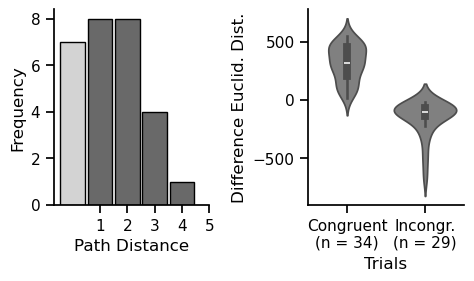

In [10]:
def axplot_eucd_diff(dt, ax=None):
    if ax is None:
        ax = plt.gca()
    def order_eucd(d):
        if d["spd_pp_diff"] > 0:
            return d["eucd_pp_diff"]
        else:
            return -d["eucd_pp_diff"]
    dt= dt[dt["subject_id"] == dt.subject_id[3]].copy()
    dt["ordered_eucd_pp_diff"] = dt.apply(order_eucd, axis=1)

    sns.violinplot(dt, x="eucd_congr", y="ordered_eucd_pp_diff", 
                   order=[True, False], color="grey", ax=ax)

    len_c = len(dt.query("eucd_congr == 1"))
    len_i = len(dt.query("eucd_congr == 0"))

    ax.set_xticks([0,1])
    ax.set_xticklabels([
        f"Congruent\n(n = {len_c})", 
        f"Incongr.\n(n = {len_i})"
    ])
    if ax.get_legend() is not None:
        ax.legend_.remove()
    ax.set_ylabel("Difference Euclid. Dist.")
    ax.set_xlabel("Trials")

    return ax

task3_rot = task3_dt[task3_dt["var_type"] == "rotational"]
fig, axs = plt.subplots(1,2, figsize=(4.9,3.0))

data = sdu.flatten_tril_mat(spd_m)
unique, counts = np.unique(data, return_counts=True)
highlight_vals = [2, 3, 4, 5]
colors = ['dimgray' if val in highlight_vals else 'lightgrey' for val in unique]
axs[0].bar(unique-1, counts, color=colors, edgecolor='black', width=0.9)
axs[0].set_xticks(range(1, 6))
axs[0].set_xlabel("Path Distance")
axs[0].set_ylabel("Frequency")

axplot_eucd_diff(task3_rot, ax=axs[1])

fig.tight_layout()

In [11]:
dt = task3_dt
dt= dt[dt["subject_id"] == dt.subject_id[3]].copy()
dt[["spd_pp_diff", "eucd_pp_diff", "wspd_pp_diff"]].corr()

,spd_pp_diff,eucd_pp_diff,wspd_pp_diff
spd_pp_diff,1.000000,0.331181,0.559747
eucd_pp_diff,0.331181,1.000000,0.157508
wspd_pp_diff,0.559747,0.157508,1.000000


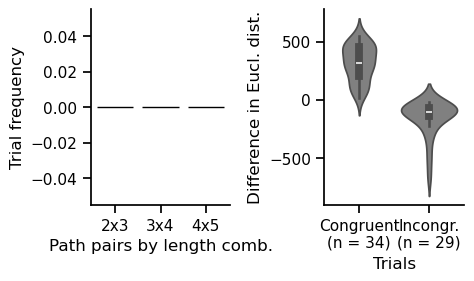

In [12]:
def axplot_eucd_diff(dt, ax=None):
    if ax is None:
        ax = plt.gca()
    def order_eucd(d):
        if d["spd_pp_diff"] > 0:
            return d["eucd_pp_diff"]
        else:
            return -d["eucd_pp_diff"]
    dt= dt[dt["subject_id"] == dt.subject_id[3]].copy()
    dt["ordered_eucd_pp_diff"] = dt.apply(order_eucd, axis=1)

    sns.violinplot(dt, x="eucd_congr", y="ordered_eucd_pp_diff", 
                # hue="eucd_congr",
                order=[True, False],
                color="grey", ax=ax)

    len_c = len(dt.query("eucd_congr == 1"))
    len_i = len(dt.query("eucd_congr == 0"))

    ax.set_xticks([0,1])
    ax.set_xticklabels([
        f"Congruent\n(n = {len_c})", 
        f"Incongr.\n(n = {len_i})"
    ])
    if ax.get_legend() is not None:
        ax.legend_.remove()
    ax.set_ylabel("Difference in Eucl. dist.")
    ax.set_xlabel("Trials")

    return ax

# Get trial pairs by path length
trial_pairs_len = { "2x3": 0, "3x4": 0, "4x5": 0, }
single_paths_len = { 2: 0, 3: 0, 4: 0, 5: 0, }

# Take example subject
trials = task3_dt.query("subject_id == '55a29d4dfdf99b602e6b069b'")["pathpair_congrtest"]

for t in trials:
    # Flatten the nested list
    flattened = [item for sublist in t for item in sublist]
    # Increment the count for the corresponding path length
    if len(flattened) == 7:
        trial_pairs_len["2x3"] += 1
    if len(flattened) == 9:
        trial_pairs_len["3x4"] += 1
    if len(flattened) == 11:
        trial_pairs_len["4x5"] += 1

    single_paths_len[len(t[0])-1] += 1
    single_paths_len[len(t[1])-1] += 1

task3_rot = task3_dt[task3_dt["var_type"] == "rotational"]
fig, axs = plt.subplots(1,2, figsize=(4.9,3.0))

axs[0].bar(trial_pairs_len.keys(), trial_pairs_len.values(), color="lightgray", edgecolor="black")
axs[0].set_xlabel("Path pairs by length comb.")
axs[0].set_ylabel("Trial frequency")

axplot_eucd_diff(task3_rot, ax=axs[1])

fig.tight_layout()

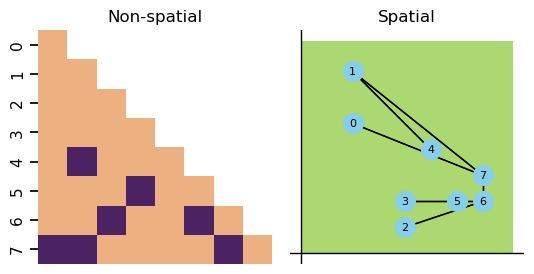

In [13]:
cmap = "flare" #"mako_r"
mask = np.triu(np.ones_like(adj_m)) + (-1)*np.eye(adj_m.shape[0])
fig, axs = plt.subplots(1,2, figsize=(5.5, 3.5))
sns.heatmap(adj_m, mask=mask, cmap=cmap, ax=axs[0], cbar=False)
spg.axplot_graph(adj_m, pos, env_size=[900, 900], ax=axs[1])
titles =  ["Non-spatial", "Spatial"]
for j, ax in enumerate(axs):
    ax.set_aspect('equal')
    ax.set_title(titles[j])
    ax.set_xticks([])
axs[1].axhline(0, color='black',linewidth=1)
axs[1].axvline(0, color='black',linewidth=1)
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")

fig.tight_layout()